<a href="https://colab.research.google.com/github/the-future-codemaster/dl_lab/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import matplotlib.pyplot as plt

# Set global font to Times New Roman and font size to 13
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13


In [2]:
# STREAMING_CHUNK:Configuring the environment and installing dependencies...
"""
CS3807 Deep Learning Laboratory - Experiment 2
Implementation of a Multi-Layer Perceptron (MLP) for Multi-Class Image Classification
Dataset: Fashion-MNIST
"""
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# STREAMING_CHUNK:Importing deep learning and evaluation libraries...

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV

In [3]:
# SciKeras wrapper is required for scikit-learn compatibility with Keras models in GridSearchCV/RandomizedSearchCV
try:
    from scikeras.wrappers import KerasClassifier
except ImportError:
    print("SciKeras not found. Please install it using: !pip install scikeras")
    raise

# Define class mappings for Fashion-MNIST based on standard documentation
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


--- TASK 1: DATASET EXPLORATION ---
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Original Training Features Shape: (60000, 28, 28)
Original Training Labels Shape: (60000,)
Original Testing Features Shape: (10000, 28, 28)
Original Testing Labels Shape: (10000,)


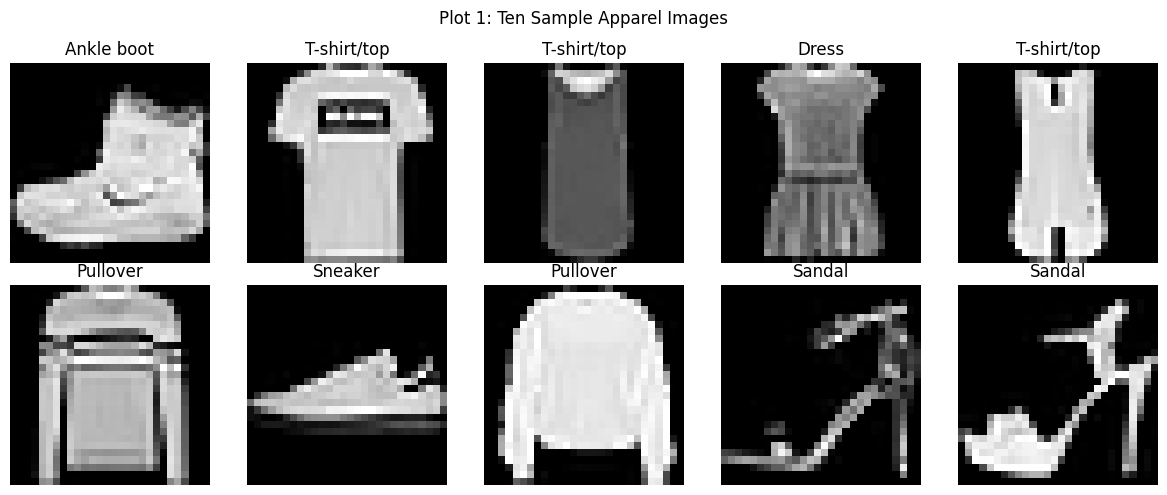

In [4]:
# STREAMING_CHUNK:Loading and exploring the Fashion-MNIST dataset...
# ==========================================
# TASK 1: Dataset Exploration
# ==========================================
print("\n--- TASK 1: DATASET EXPLORATION ---")
# Loading the raw apparel dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = fashion_mnist.load_data()

print(f"Original Training Features Shape: {x_train_raw.shape}")
print(f"Original Training Labels Shape: {y_train_raw.shape}")
print(f"Original Testing Features Shape: {x_test_raw.shape}")
print(f"Original Testing Labels Shape: {y_test_raw.shape}")

# Plot 1: Sample Images Exploration
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(CLASS_NAMES[y_train_raw[i]])
    plt.axis('off')
plt.suptitle("Plot 1: Ten Sample Apparel Images")
plt.tight_layout()
plt.show()

/tmp/ipykernel_631/1596113292.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_raw, palette='viridis')


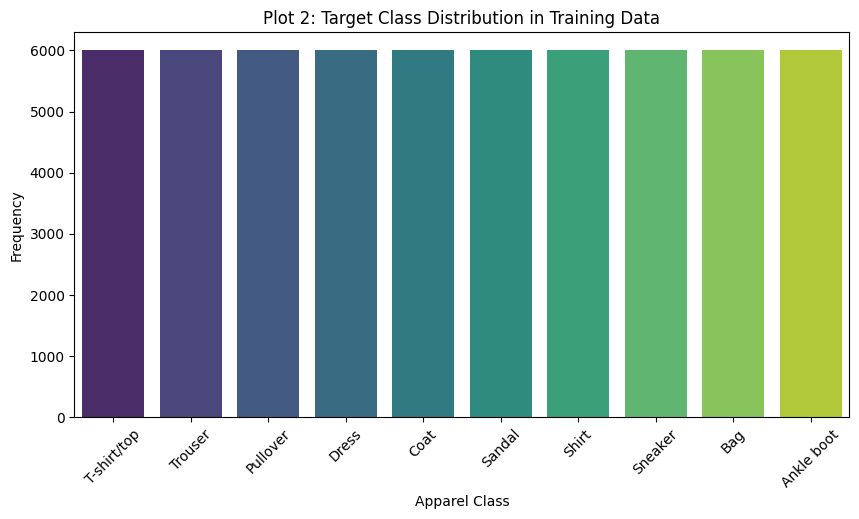

In [5]:
# STREAMING_CHUNK:Visualizing class distributions and preparing tensors...
# Plot 2: Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_raw, palette='viridis')
plt.xticks(ticks=range(10), labels=CLASS_NAMES, rotation=45)
plt.title("Plot 2: Target Class Distribution in Training Data")
plt.xlabel("Apparel Class")
plt.ylabel("Frequency")
plt.show()

In [6]:
# ==========================================
# TASK 2: Data Preprocessing
# ==========================================
print("\n--- TASK 2: DATA PREPROCESSING ---")
# Vectorizing the 28x28 spatial matrices into 784-dimensional flat arrays for the Dense layers
x_train_flat = x_train_raw.reshape(x_train_raw.shape[0], 784)
x_test_flat = x_test_raw.reshape(x_test_raw.shape[0], 784)

# Min-Max Normalization to scale pixel intensities to [0.0, 1.0] to stabilize gradient updates
x_train_norm = x_train_flat.astype('float32') / 255.0
x_test_norm = x_test_flat.astype('float32') / 255.0

# STREAMING_CHUNK:Encoding labels and constructing the baseline model architecture...
# Transforming scalar labels into one-hot encoded vectors for Categorical Cross-Entropy
y_train_cat = to_categorical(y_train_raw, num_classes=10)
y_test_cat = to_categorical(y_test_raw, num_classes=10)

print(f"Preprocessed Training Features Shape: {x_train_norm.shape}")
print(f"Preprocessed Training Labels Shape: {y_train_cat.shape}")


--- TASK 2: DATA PREPROCESSING ---
Preprocessed Training Features Shape: (60000, 784)
Preprocessed Training Labels Shape: (60000, 10)


In [7]:
# ==========================================
# TASK 3: Model Construction (Baseline)
# ==========================================
print("\n--- TASK 3: BASELINE MODEL CONSTRUCTION ---")
baseline_model = Sequential(name="Baseline_MLP")
baseline_model.add(Input(shape=(784,), name="Input_Flattened_Layer"))
baseline_model.add(Dense(128, activation='relu', name="Hidden_Layer_1"))
baseline_model.add(Dense(64, activation='relu', name="Hidden_Layer_2"))
baseline_model.add(Dense(10, activation='softmax', name="Output_Layer"))

baseline_model.summary()


--- TASK 3: BASELINE MODEL CONSTRUCTION ---


Model: "Baseline_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# STREAMING_CHUNK:Compiling and executing the baseline training loop...
# ==========================================
# TASK 4: Model Training (Baseline)
# ==========================================
print("\n--- TASK 4: BASELINE MODEL TRAINING ---")
baseline_model.compile(optimizer=Adam(),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Measuring training time
start_time_base = time.time()
baseline_history = baseline_model.fit(x_train_norm, y_train_cat,
                                      epochs=20,
                                      batch_size=32,
                                      validation_split=0.1,
                                      verbose=1)
train_time_base = time.time() - start_time_base


--- TASK 4: BASELINE MODEL TRAINING ---
Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8220 - loss: 0.5021 - val_accuracy: 0.8623 - val_loss: 0.3882
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8641 - loss: 0.3707 - val_accuracy: 0.8690 - val_loss: 0.3558
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8757 - loss: 0.3351 - val_accuracy: 0.8742 - val_loss: 0.3411
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8851 - loss: 0.3115 - val_accuracy: 0.8672 - val_loss: 0.3486
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8907 - loss: 0.2939 - val_accuracy: 0.8818 - val_loss: 0.3284
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8953 - loss: 0.2800 - val_accuracy: 0.8827 - val_loss: 0.3248
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8995 - loss: 0.2667 - val_accuracy: 0.8797 - val_loss: 0.3530
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms

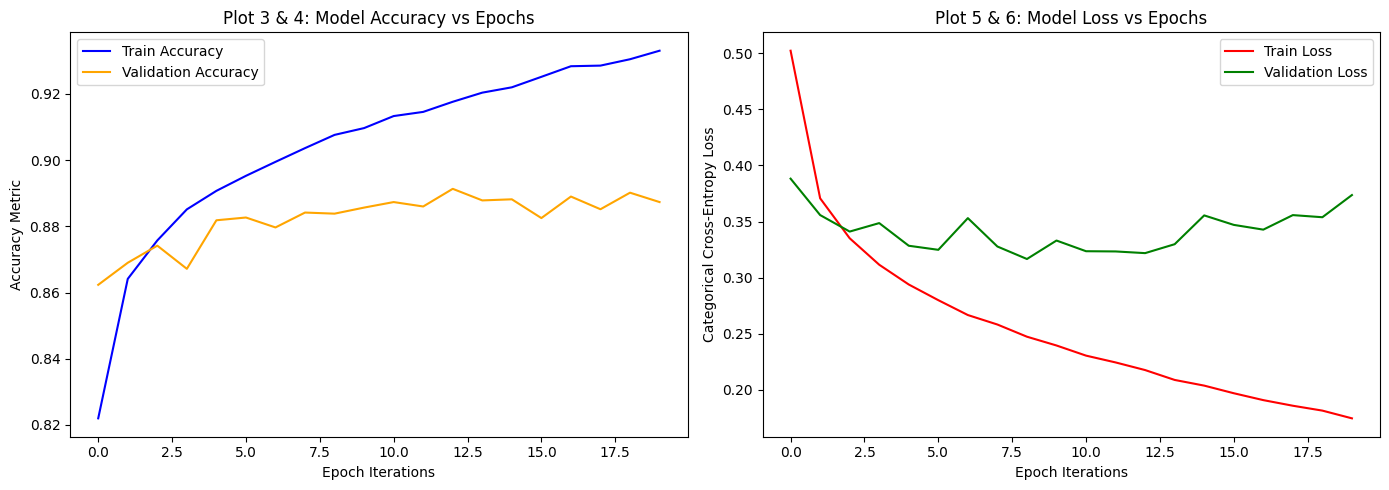

In [9]:
# STREAMING_CHUNK:Plotting learning curves for the baseline model...
# Plot 3 & 5: Training/Validation Accuracy and Loss
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax[0].plot(baseline_history.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_title("Plot 3 & 4: Model Accuracy vs Epochs")
ax[0].set_xlabel("Epoch Iterations")
ax[0].set_ylabel("Accuracy Metric")
ax[0].legend()

# Loss Plot
ax[1].plot(baseline_history.history['loss'], label='Train Loss', color='red')
ax[1].plot(baseline_history.history['val_loss'], label='Validation Loss', color='green')
ax[1].set_title("Plot 5 & 6: Model Loss vs Epochs")
ax[1].set_xlabel("Epoch Iterations")
ax[1].set_ylabel("Categorical Cross-Entropy Loss")
ax[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# STREAMING_CHUNK:Evaluating the baseline predictions and generating the confusion matrix...
# ==========================================
# TASK 5: Model Evaluation (Baseline)
# ==========================================
print("\n--- TASK 5: BASELINE MODEL EVALUATION ---")
y_pred_probs_base = baseline_model.predict(x_test_norm)
y_pred_base = np.argmax(y_pred_probs_base, axis=1)

# Calculating standard metrics
base_acc = accuracy_score(y_test_raw, y_pred_base)
base_prec = precision_score(y_test_raw, y_pred_base, average='weighted')
base_rec = recall_score(y_test_raw, y_pred_base, average='weighted')
base_f1 = f1_score(y_test_raw, y_pred_base, average='weighted')

print(f"Baseline Accuracy: {base_acc:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_raw, y_pred_base, target_names=CLASS_NAMES))


--- TASK 5: BASELINE MODEL EVALUATION ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Accuracy: 0.8875
Baseline Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.86      0.85      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.77      0.85      0.81      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.85      0.75      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.69      0.70      0.69      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



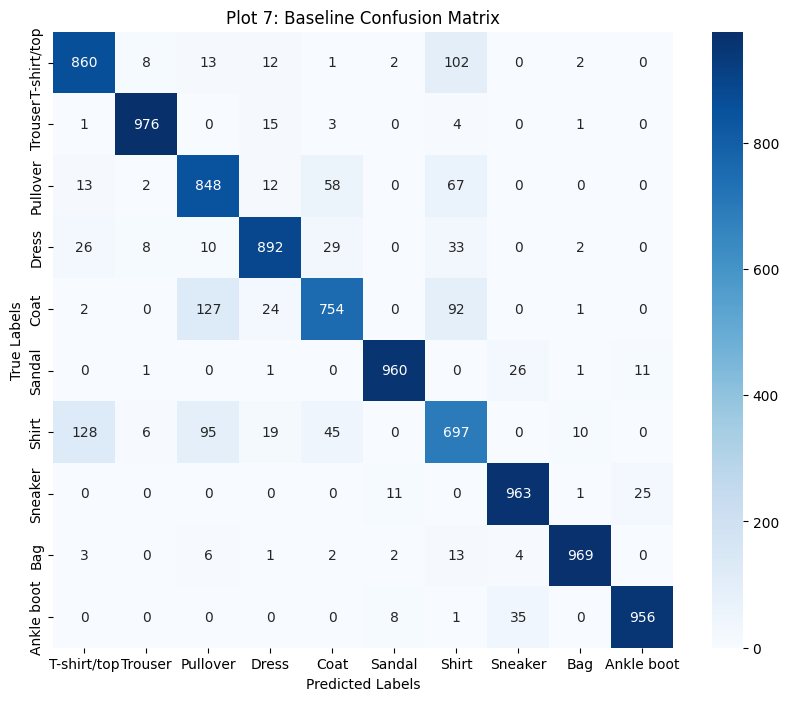

In [11]:
# Plot 7: Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_raw, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Plot 7: Baseline Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [14]:
# STREAMING_CHUNK:Defining the dynamic model architecture for rigorous hyperparameter tuning...
# ==========================================
# TASK 6 & 7: HYPERPARAMETER OPTIMIZATION
# ==========================================
print("\n--- TASK 6 & 7: HYPERPARAMETER OPTIMIZATION (RANDOMIZED SEARCH) ---")

# Initialize a global counter to track the 75 fits (15 iterations * 5 folds)
iteration_counter = 0

# Dynamic architecture builder for SciKeras to accommodate the full search space
def build_mlp_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                    optimizer_name='adam', activation_func='relu', dropout_rate=0.0):

    # Increment and print the custom counter
    global iteration_counter
    iteration_counter += 1
    print(f"\n>>> [Progress Indicator] Building and training model {iteration_counter} out of 75 <<<")

    model = Sequential()
    model.add(Input(shape=(784,)))

    # Dynamically constructing hidden layers based on the search parameter
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation_func))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    # Optimizer selection logic
    if optimizer_name == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_wrapper = KerasClassifier(
    model=build_mlp_model,
    hidden_layers=2,
    hidden_neurons=64,
    learning_rate=0.001,
    optimizer_name='adam',
    activation_func='relu',
    dropout_rate=0.0,
    verbose=0
)

# STREAMING_CHUNK:Configuring the comprehensive search space...
param_dist = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'activation_func': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5]
}

print("Initiating RandomizedSearchCV with 5-fold cross-validation...")
print("Executing across the entire dataset.")

# n_jobs=1 ensures it runs sequentially to prevent Colab RAM crashes
random_search = RandomizedSearchCV(
    estimator=model_wrapper,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    n_jobs=1,
    verbose=2,
    random_state=42
)

# STREAMING_CHUNK:Executing the intensive hyperparameter optimization over the complete training set...
# Applying fit on the FULL training dataset without any slicing or constraints
start_time_opt = time.time()
random_search_result = random_search.fit(x_train_norm, y_train_cat)
train_time_opt = time.time() - start_time_opt

# STREAMING_CHUNK:Extracting optimized parameters and generating high-resolution EPS visualizations...
best_params = random_search_result.best_params_
best_score = random_search_result.best_score_

print("\nBest Hyperparameter Configuration Discovered:")
for key, value in best_params.items():
    print(f" - {key}: {value}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")


--- TASK 6 & 7: HYPERPARAMETER OPTIMIZATION (RANDOMIZED SEARCH) ---
Initiating RandomizedSearchCV with 5-fold cross-validation...
Executing across the entire dataset.
Fitting 5 folds for each of 15 candidates, totalling 75 fits

>>> [Progress Indicator] Building and training model 1 out of 75 <<<
[CV] END activation_func=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=  23.9s

>>> [Progress Indicator] Building and training model 2 out of 75 <<<
[CV] END activation_func=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=  22.9s

>>> [Progress Indicator] Building and training model 3 out of 75 <<<
[CV] END activation_func=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=  23.9s

>>> [Progress Indicator] Building and 

/tmp/ipykernel_631/1821187078.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['mean_test_score'], palette='coolwarm')


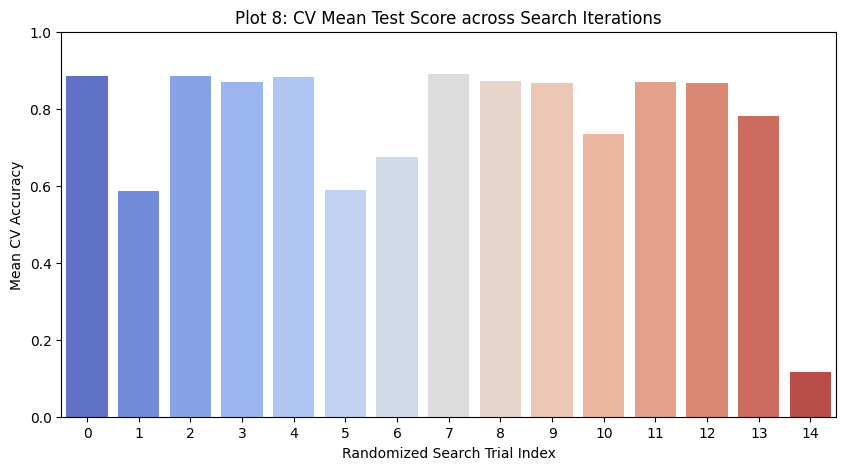

In [15]:
# Plot 8: Hyperparameter Search Results Visualization (Exported as 600 DPI EPS)
results_df = pd.DataFrame(random_search_result.cv_results_)
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df['mean_test_score'], palette='coolwarm')
plt.title("Plot 8: CV Mean Test Score across Search Iterations")
plt.xlabel("Randomized Search Trial Index")
plt.ylabel("Mean CV Accuracy")
plt.ylim(0, 1.0)

# Saving as high-quality EPS for LaTeX embedding
plt.savefig('Plot_8_Hyperparameter_Search.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [16]:
# STREAMING_CHUNK:Evaluating the fully optimized neural network on the unseen testing manifold...
# Extracting and evaluating the supreme model
best_model = random_search_result.best_estimator_
y_pred_probs_opt = best_model.predict(x_test_norm)

# Handling array shape discrepancies depending on SciKeras backend execution
if len(y_pred_probs_opt.shape) > 1 and y_pred_probs_opt.shape[1] > 1:
    y_pred_opt = np.argmax(y_pred_probs_opt, axis=1)
else:
    y_pred_opt = np.argmax(y_pred_probs_opt, axis=1) if len(y_pred_probs_opt.shape) == 2 else y_pred_probs_opt

opt_acc = accuracy_score(y_test_raw, y_pred_opt)
opt_prec = precision_score(y_test_raw, y_pred_opt, average='weighted', zero_division=0)
opt_rec = recall_score(y_test_raw, y_pred_opt, average='weighted', zero_division=0)
opt_f1 = f1_score(y_test_raw, y_pred_opt, average='weighted', zero_division=0)

<Figure size 800x500 with 0 Axes>

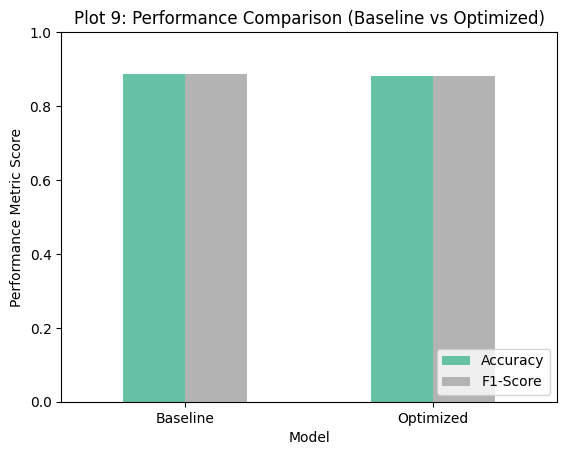

In [17]:
# STREAMING_CHUNK:Generating Plot 9 in EPS format and formatting the final comparative metrics...
# Plot 9: Best Model Accuracy Comparison (Exported as 600 DPI EPS)
metrics_df = pd.DataFrame({
    'Model': ['Baseline', 'Optimized'],
    'Accuracy': [base_acc, opt_acc],
    'F1-Score': [base_f1, opt_f1]
})

plt.figure(figsize=(8, 5))
metrics_df.set_index('Model').plot.bar(rot=0, colormap='Set2')
plt.title("Plot 9: Performance Comparison (Baseline vs Optimized)")
plt.ylabel("Performance Metric Score")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')

# Saving the comparison plot as high-quality EPS
plt.savefig('Plot_9_Accuracy_Comparison.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

### Regenerated Plots with Requested Formatting

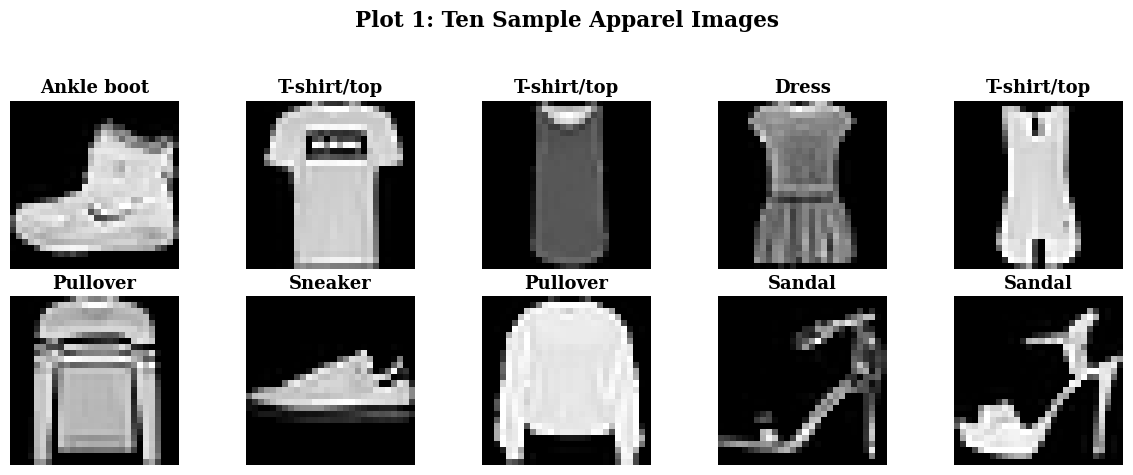

In [19]:
# Regenerated Plot 1: Sample Images Exploration
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(CLASS_NAMES[y_train_raw[i]], fontweight='bold') # Apply bold to subplot titles
    plt.axis('off')
plt.suptitle("Plot 1: Ten Sample Apparel Images", fontweight='bold') # Apply bold to suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.savefig('Plot_1_Sample_Images.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

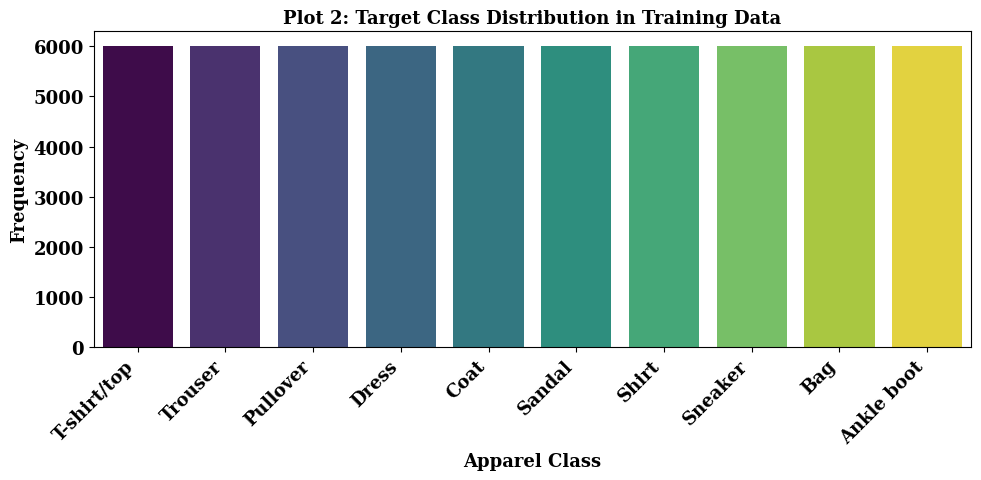

In [20]:
# Regenerated Plot 2: Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_raw, hue=y_train_raw, palette='viridis', legend=False) # Use hue for palette and set legend=False to prevent warning
plt.xticks(ticks=range(10), labels=CLASS_NAMES, rotation=45, ha='right', fontweight='bold') # Bold x-axis ticks
plt.yticks(fontweight='bold') # Bold y-axis ticks
plt.title("Plot 2: Target Class Distribution in Training Data", fontweight='bold')
plt.xlabel("Apparel Class", fontweight='bold')
plt.ylabel("Frequency", fontweight='bold')
plt.tight_layout()
plt.savefig('Plot_2_Class_Distribution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

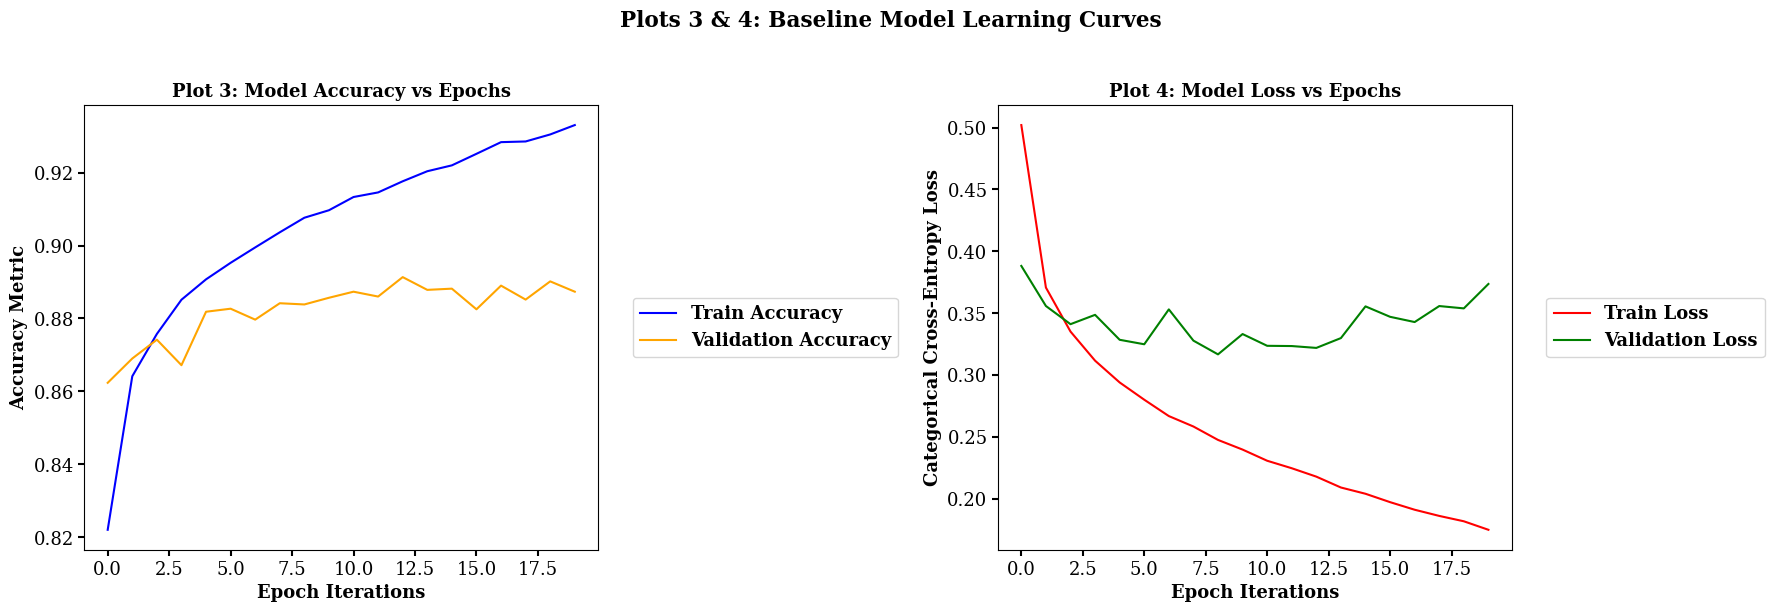

In [29]:
import matplotlib.pyplot as plt

# Regenerated Plots 3 & 4: Training/Validation Accuracy and Loss
fig, ax = plt.subplots(1, 2, figsize=(18, 6)) # Increased figure size

# Accuracy Plot
ax[0].plot(baseline_history.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_title("Plot 3: Model Accuracy vs Epochs", fontweight='bold')
ax[0].set_xlabel("Epoch Iterations", fontweight='bold')
ax[0].set_ylabel("Accuracy Metric", fontweight='bold')
ax[0].tick_params(axis='x', labelbottom=True, which='both', bottom=True, top=False, labeltop=False, width=1.5, length=4)
ax[0].tick_params(axis='y', labelleft=True, which='both', left=True, right=False, labelright=False, width=1.5, length=4)
ax[0].legend(loc='center left', bbox_to_anchor=(1.05, 0.5), prop={'weight':'bold'}) # Adjusted legend placement

# Loss Plot
ax[1].plot(baseline_history.history['loss'], label='Train Loss', color='red')
ax[1].plot(baseline_history.history['val_loss'], label='Validation Loss', color='green')
ax[1].set_title("Plot 4: Model Loss vs Epochs", fontweight='bold')
ax[1].set_xlabel("Epoch Iterations", fontweight='bold')
ax[1].set_ylabel("Categorical Cross-Entropy Loss", fontweight='bold')
ax[1].tick_params(axis='x', labelbottom=True, which='both', bottom=True, top=False, labeltop=False, width=1.5, length=4)
ax[1].tick_params(axis='y', labelleft=True, which='both', left=True, right=False, labelright=False, width=1.5, length=4)
ax[1].legend(loc='center left', bbox_to_anchor=(1.05, 0.5), prop={'weight':'bold'}) # Adjusted legend placement

plt.suptitle("Plots 3 & 4: Baseline Model Learning Curves", y=1.02, fontweight='bold') # Central suptitle for both plots
plt.tight_layout() # Let tight_layout handle spacing with the new bbox_to_anchor
plt.savefig('Plot_3_4_Learning_Curves.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

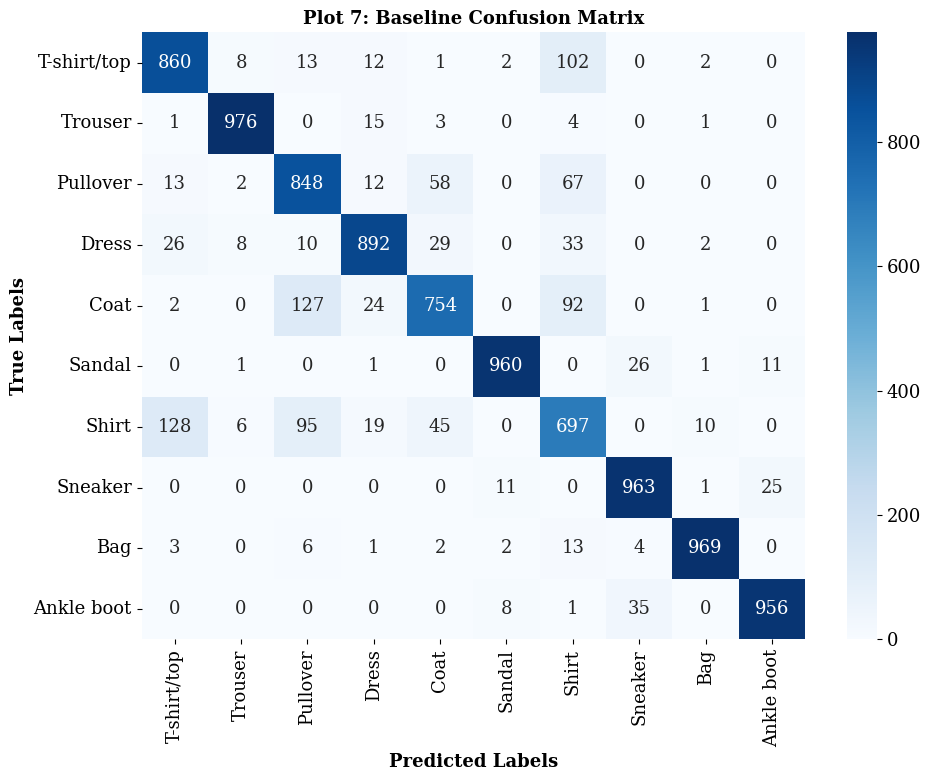

In [22]:
# Regenerated Plot 7: Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_raw, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Plot 7: Baseline Confusion Matrix", fontweight='bold')
plt.xlabel("Predicted Labels", fontweight='bold')
plt.ylabel("True Labels", fontweight='bold')
plt.tight_layout()
plt.savefig('Plot_7_Baseline_Confusion_Matrix.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

/tmp/ipykernel_631/1024344133.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['mean_test_score'], palette='coolwarm') # 'hue' not explicitly needed for this plot type with palette for individual bars


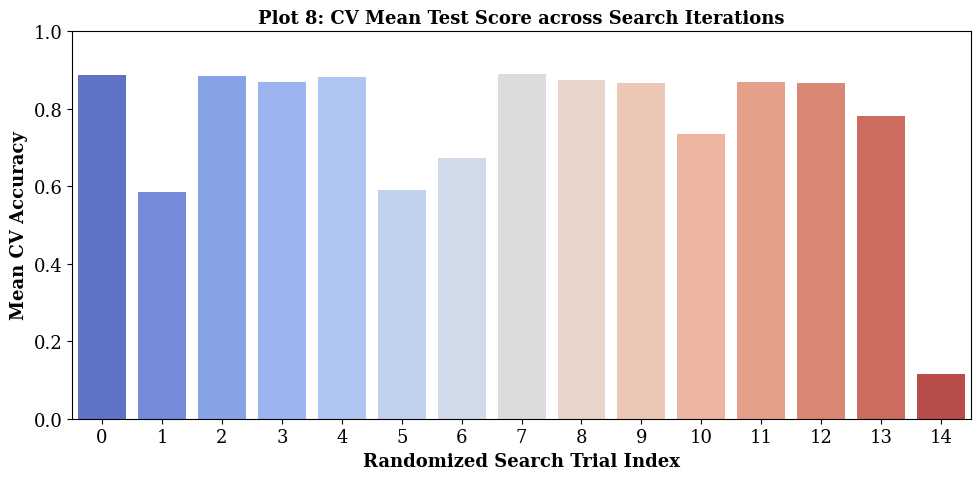

In [23]:
# Regenerated Plot 8: Hyperparameter Search Results Visualization
results_df = pd.DataFrame(random_search_result.cv_results_)
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df['mean_test_score'], palette='coolwarm') # 'hue' not explicitly needed for this plot type with palette for individual bars
plt.title("Plot 8: CV Mean Test Score across Search Iterations", fontweight='bold')
plt.xlabel("Randomized Search Trial Index", fontweight='bold')
plt.ylabel("Mean CV Accuracy", fontweight='bold')
plt.ylim(0, 1.0)
plt.tight_layout()
# Saving as high-quality EPS for LaTeX embedding
plt.savefig('Plot_8_Hyperparameter_Search.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

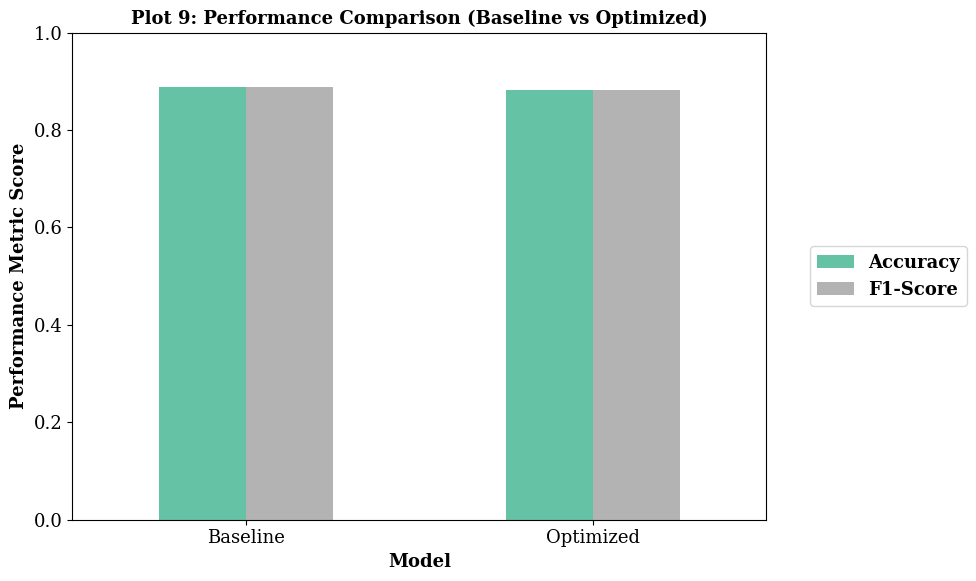

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Regenerated Plot 9: Best Model Accuracy Comparison
metrics_df = pd.DataFrame({
    'Model': ['Baseline', 'Optimized'],
    'Accuracy': [base_acc, opt_acc],
    'F1-Score': [base_f1, opt_f1]
})

plt.figure(figsize=(10, 6)) # Increased figure size
ax = metrics_df.set_index('Model').plot.bar(rot=0, colormap='Set2', ax=plt.gca()) # Plot on current axes
plt.title("Plot 9: Performance Comparison (Baseline vs Optimized)", fontweight='bold')
plt.xlabel("Model", fontweight='bold') # Added bold xlabel
plt.ylabel("Performance Metric Score", fontweight='bold')
plt.ylim(0, 1.0)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), prop={'weight':'bold'}) # Adjusted legend placement
plt.tight_layout() # Let tight_layout handle spacing with the new bbox_to_anchor
# Saving the comparison plot as high-quality EPS
plt.savefig('Plot_9_Accuracy_Comparison.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

### Separated and Enlarged Plots 3 and 4

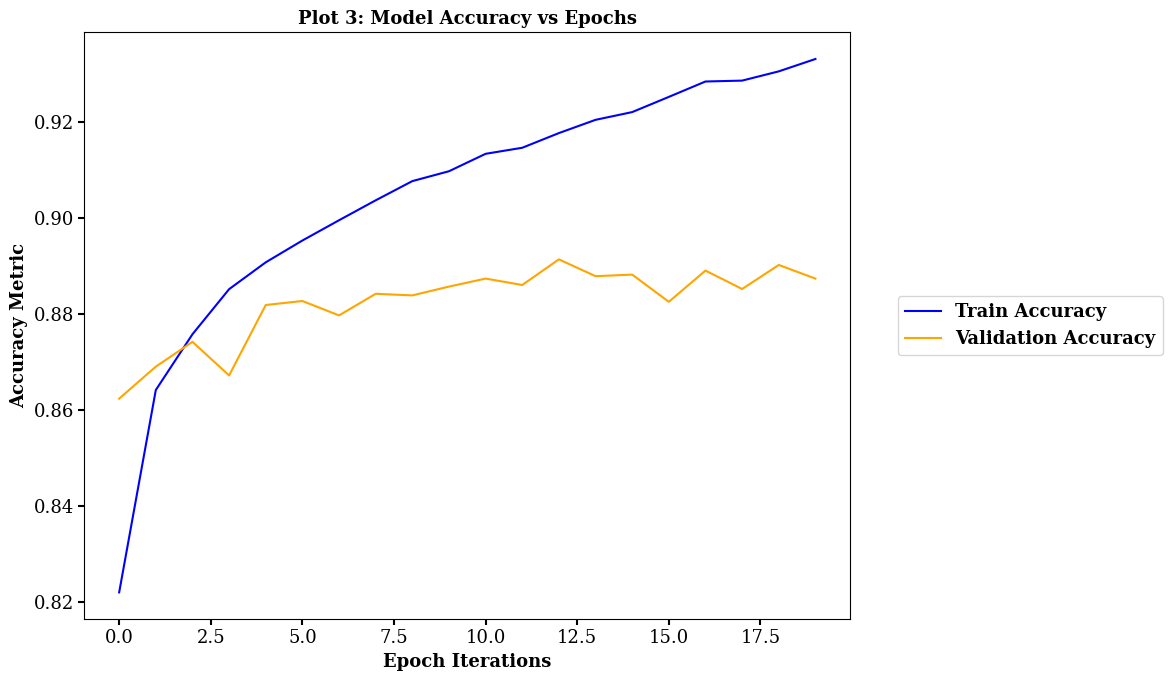

In [31]:
import matplotlib.pyplot as plt

# Regenerated Plot 3: Model Accuracy vs Epochs (Separated and Enlarged)
plt.figure(figsize=(12, 7)) # Increased figure size for individual plot
plt.plot(baseline_history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title("Plot 3: Model Accuracy vs Epochs", fontweight='bold')
plt.xlabel("Epoch Iterations", fontweight='bold')
plt.ylabel("Accuracy Metric", fontweight='bold')
plt.tick_params(axis='x', labelbottom=True, which='both', bottom=True, top=False, labeltop=False, width=1.5, length=4)
plt.tick_params(axis='y', labelleft=True, which='both', left=True, right=False, labelright=False, width=1.5, length=4)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), prop={'weight':'bold'}) # Legend outside and bold
plt.tight_layout() # Let tight_layout handle spacing
plt.savefig('Plot_3_Accuracy.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

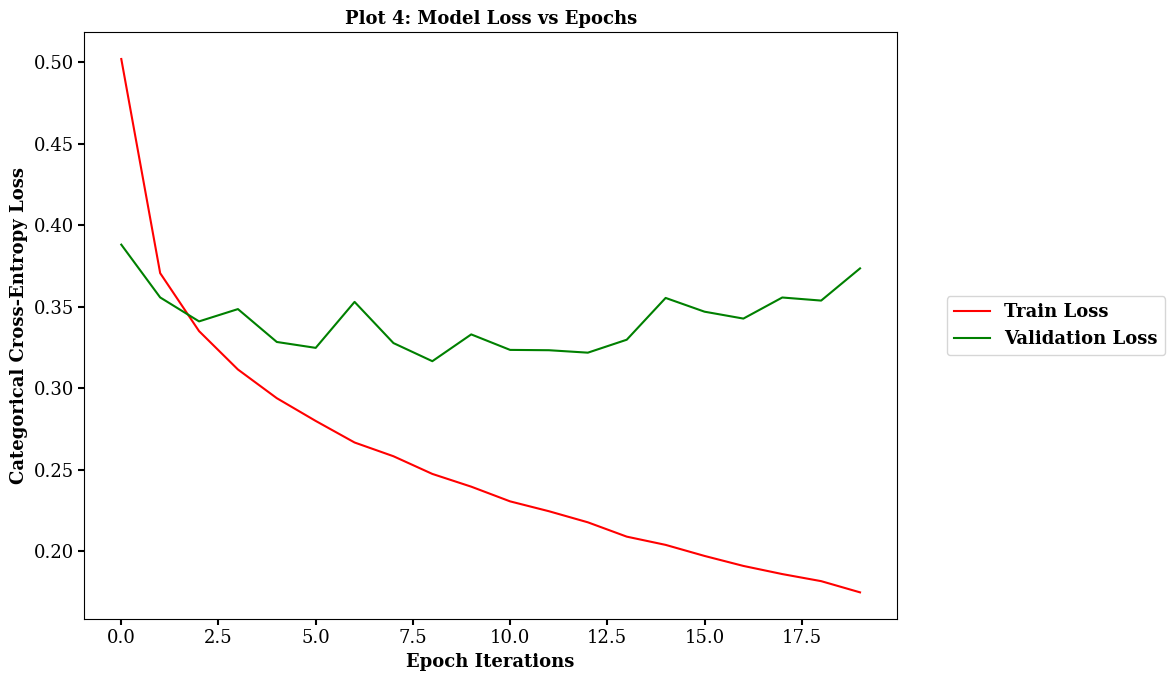

In [32]:
import matplotlib.pyplot as plt

# Regenerated Plot 4: Model Loss vs Epochs (Separated and Enlarged)
plt.figure(figsize=(12, 7)) # Increased figure size for individual plot
plt.plot(baseline_history.history['loss'], label='Train Loss', color='red')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss', color='green')
plt.title("Plot 4: Model Loss vs Epochs", fontweight='bold')
plt.xlabel("Epoch Iterations", fontweight='bold')
plt.ylabel("Categorical Cross-Entropy Loss", fontweight='bold')
plt.tick_params(axis='x', labelbottom=True, which='both', bottom=True, top=False, labeltop=False, width=1.5, length=4)
plt.tick_params(axis='y', labelleft=True, which='both', left=True, right=False, labelright=False, width=1.5, length=4)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), prop={'weight':'bold'}) # Legend outside and bold
plt.tight_layout() # Let tight_layout handle spacing
plt.savefig('Plot_4_Loss.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()